In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from IPython.display import display

In [2]:
conn = sqlite3.connect('yelp.db')

tables = pd.read_sql_query('SELECT name FROM sqlite_master WHERE type="table"', conn)
print(tables)

conn.close()

       name
0  business
1   checkin
2      tips
3   reviews


In [3]:
conn = sqlite3.connect('yelp.db')

for table in tables['name']:
    df = pd.read_sql_query(f'SELECT * FROM {table} LIMIT 5', conn)
    display(df)

conn.close()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [4]:
conn = sqlite3.connect('yelp.db')

restaurant_reviews_count_df = pd.read_sql_query('''
SELECT
    b.business_id,
    b.name,
    b.stars AS 'avg_rating',
    COUNT(r.review_id) AS 'reviews_count'
FROM business b
LEFT JOIN reviews r
    ON b.business_id = r.business_id
WHERE LOWER(b.categories) LIKE '%restaurant%'
  AND b.is_open = 1
GROUP BY
    b.business_id,
    b.name,
    b.stars
ORDER BY reviews_count DESC;
''', conn)

conn.close()

In [5]:
display(restaurant_reviews_count_df)

,business_id,name,avg_rating,reviews_count
0,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,4.0,7673
1,ac1AeYqs8Z4_e2X5M3if2A,Oceana Grill,4.0,7516
2,GXFMD0Z4jEVZBCsbPf4CTQ,Hattie B’s Hot Chicken - Nashville,4.5,6160
3,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,4.5,5778
4,oBNrLz4EDhiscSlbOl8uAw,Ruby Slipper - New Orleans,4.5,5264
...,...,...,...,...
34999,zgwu3yTttj50W5-z1lE42Q,NOLA Veggie Fest,4.0,5
35000,zh_TSrF9qJFV_f3kBWyRGg,Waffle House,3.0,5
35001,zlsiRDDtKYwxrnF9NomQnw,China King,2.0,5
35002,zoAZydP_v380Yydf-2u3hw,The Mobile Bistro,5.0,5


<Axes: xlabel='reviews_count', ylabel='avg_rating'>

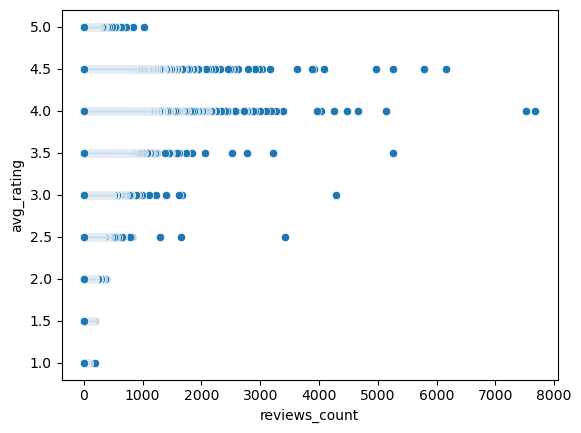

In [6]:
sns.scatterplot(data=restaurant_reviews_count_df, x='reviews_count', y='avg_rating')

In [7]:
conn = sqlite3.connect('yelp.db')

restaurant_tips_count_df = pd.read_sql_query('''
SELECT
    b.business_id,
    b.name,
    b.stars AS 'avg_rating',
    COUNT(t.business_id) AS 'tips_count'
FROM business b
LEFT JOIN tips t
    ON b.business_id = t.business_id
WHERE LOWER(b.categories) LIKE '%restaurant%'
  AND b.is_open = 1
GROUP BY
    b.business_id,
    b.name,
    b.stars
ORDER BY tips_count DESC;
''', conn)

conn.close()

In [8]:
display(restaurant_tips_count_df)

,business_id,name,avg_rating,tips_count
0,FEXhWNCMkv22qG04E83Qjg,Café Du Monde,4.0,2571
1,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,4.0,932
2,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,4.5,827
3,ac1AeYqs8Z4_e2X5M3if2A,Oceana Grill,4.0,613
4,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,4.0,608
...,...,...,...,...
34999,zuObDJ16rxyt5ciCbhKnlA,Luis's Garden Grill,5.0,0
35000,zxY4DgtXsVHihSUpsmwamg,P & S Ravioli,4.5,0
35001,zz07slKrNwzX_1uiF8QL6g,La Tapanade,1.5,0
35002,zzXRdzrVhfNWPHD2MeyWeA,Royal Farms,2.0,0


<Axes: xlabel='tips_count', ylabel='avg_rating'>

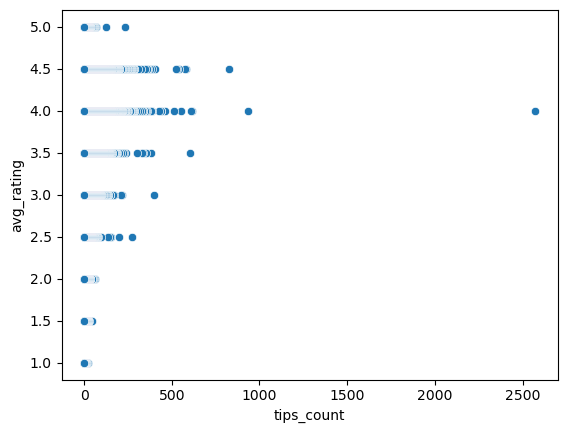

In [9]:
sns.scatterplot(data=restaurant_tips_count_df, x='tips_count', y='avg_rating')

In [10]:
conn = sqlite3.connect('yelp.db')

restaurant_checkin_count_df = pd.read_sql_query('''
SELECT
    b.business_id,
    b.name,
    b.stars AS 'avg_rating',
    CASE
        WHEN c.date IS NULL OR TRIM(c.date) = '' THEN 0
        ELSE LENGTH(c.date) - LENGTH(REPLACE(c.date, ',', '')) + 1
    END AS 'checkin_count'
FROM business b
LEFT JOIN checkin c
    ON b.business_id = c.business_id
WHERE LOWER(b.categories) LIKE '%restaurant%'
  AND b.is_open = 1
GROUP BY
    b.business_id,
    b.name,
    b.stars
ORDER BY checkin_count DESC
''', conn)

conn.close()

In [11]:
display(restaurant_checkin_count_df)

,business_id,name,avg_rating,checkin_count
0,FEXhWNCMkv22qG04E83Qjg,Café Du Monde,4.0,40109
1,VQcCL9PiNL_wkGf-uF3fjg,Royal House,4.0,28927
2,ac1AeYqs8Z4_e2X5M3if2A,Oceana Grill,4.0,21542
3,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,4.5,18615
4,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,4.0,15205
...,...,...,...,...
34999,zRgFle8xIP66TzUHjN4RDQ,Buon Appetito,3.0,0
35000,zWilCoi_idXD7Xn0RMwZVA,Starlite Cruises,4.0,0
35001,zbVfCjygZ5W6Qj5cTVF51Q,Van Pelt Hot Dog,4.5,0
35002,zfZYXlPm2zyvKFxMt1N1MA,Fini's Italian Deli,3.5,0


<Axes: xlabel='checkin_count', ylabel='avg_rating'>

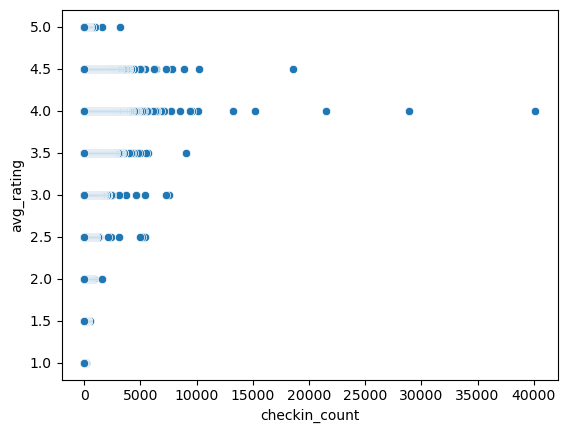

In [12]:
sns.scatterplot(data=restaurant_checkin_count_df, x='checkin_count', y='avg_rating')

In [13]:
avg_engagement = (restaurant_reviews_count_df
    .merge(restaurant_tips_count_df, on='business_id', how='left')
    .merge(restaurant_checkin_count_df, on='business_id', how='left')).groupby('avg_rating')[['reviews_count', 'tips_count', 'checkin_count']].mean()

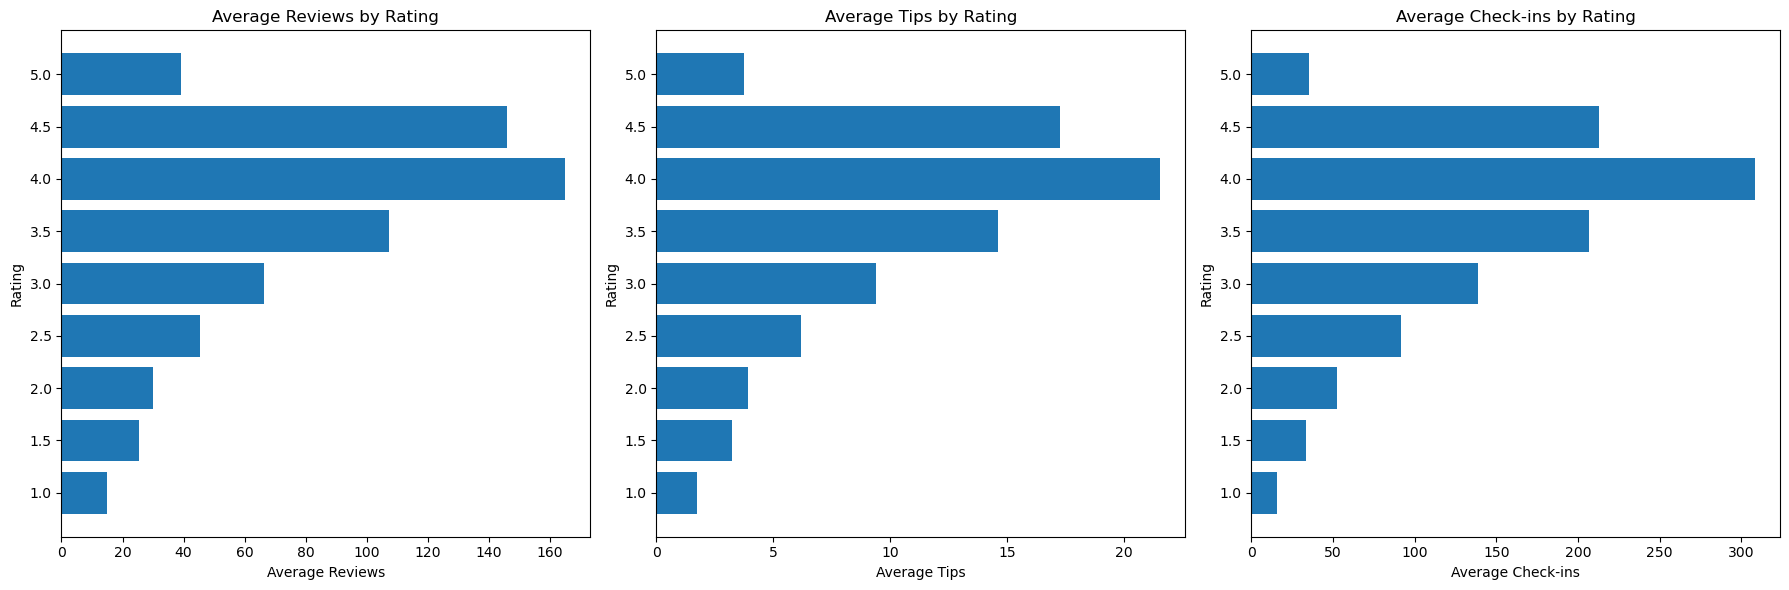

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reviews
axes[0].barh(
    avg_engagement.index.astype(str),
    avg_engagement["reviews_count"]
)
axes[0].set_title("Average Reviews by Rating")
axes[0].set_xlabel("Average Reviews")
axes[0].set_ylabel("Rating")

# Tips
axes[1].barh(
    avg_engagement.index.astype(str),
    avg_engagement["tips_count"]
)
axes[1].set_title("Average Tips by Rating")
axes[1].set_xlabel("Average Tips")
axes[1].set_ylabel("Rating")

# Check-ins
axes[2].barh(
    avg_engagement.index.astype(str),
    avg_engagement["checkin_count"]
)
axes[2].set_title("Average Check-ins by Rating")
axes[2].set_xlabel("Average Check-ins")
axes[2].set_ylabel("Rating")

plt.tight_layout()
plt.show()

In [15]:
df = (restaurant_reviews_count_df
    .merge(restaurant_tips_count_df, on='business_id', how='left')
    .merge(restaurant_checkin_count_df, on='business_id', how='left'))

In [16]:
corr = df[['reviews_count', 'tips_count', 'checkin_count', 'avg_rating']].corr()

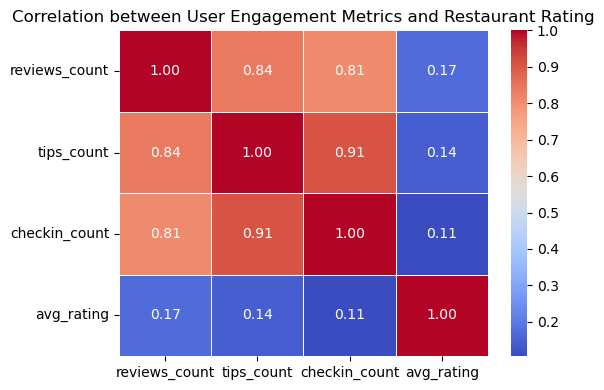

In [17]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation between User Engagement Metrics and Restaurant Rating')
plt.tight_layout()
plt.show()